In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("✅ Libraries imported!")

✅ Libraries imported!


In [10]:
import io

csv_data = """RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
1,15634602,Hargrave,619,France,Female,42,2,0,1,1,1,101348.88,1
2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
3,15619304,Onio,502,France,Female,42,8,159660.8,3,1,0,113931.57,1
4,15701354,Boni,699,France,Female,39,1,0,2,0,0,93826.63,0
5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.1,0
6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
7,15592531,Bartlett,822,France,Male,50,7,0,2,1,1,10062.8,0
8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.5,0
10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0
11,15767821,Nguyen,528,France,Male,31,6,102016.72,2,0,0,80181.12,0
12,15737173,Henderson,497,France,Male,24,3,0,2,1,0,76390.01,0
13,15632264,Johansson,476,Germany,Female,34,10,57369.61,1,1,0,26260.98,0
14,15691483,Long,549,France,Male,25,5,0,2,0,0,190857.79,0
15,15706195,Zheng,635,Germany,Female,35,7,0,2,1,1,65951.65,0
16,15600882,Gao,616,Germany,Male,45,3,143129.41,2,0,1,64327.26,1
17,15788218,Mann,653,Germany,Male,58,1,132602.88,1,1,0,5097.67,1
18,15661507,Li,549,France,Male,24,9,0,2,1,1,14406.41,0
19,15681529,Hewitt,587,Spain,Male,45,6,0,1,0,0,158684.81,0
20,15693014,Andersen,726,France,Male,24,6,0,2,1,1,93210.36,0
21,15706426,Anderson,732,France,Male,44,8,142448.98,2,1,1,86908.49,0
22,15791412,Perrier,636,Germany,Female,35,3,0,2,1,0,52627.93,0
23,15569887,Pitt,510,France,Female,39,3,111375.2,2,1,1,82671.9,0
24,15794419,McGregor,669,France,Female,25,5,0,2,0,1,64539.3,0
25,15606280,Walsh,846,France,Male,54,5,0,2,1,1,176071.34,0
26,15741522,Watkins,613,Germany,Male,42,3,148725.57,2,0,0,149668.85,1
27,15591437,Smith,555,France,Male,39,2,107499.3,2,1,1,94101.51,1
28,15589716,Becker,432,France,Male,58,8,0,1,1,0,120393.52,0
29,15666172,Baker,516,Germany,Male,41,8,0,2,0,1,25163.72,0
30,15584532,Simpson,562,Germany,Female,32,4,91293.88,2,1,1,182808.29,0
31,15757932,Parker,687,Germany,Male,37,9,0,2,1,1,19834.84,0
32,15681598,Jones,524,Germany,Female,27,7,149135.45,2,1,1,17509.45,0
33,15619173,Clark,552,France,Male,29,3,0,2,0,1,137811.23,0
34,15691809,Nguyen,712,Germany,Male,42,4,161282.34,2,0,1,122776.73,1
35,15639193,Wood,655,France,Female,57,5,0,1,1,1,75763.46,0
36,15730820,Harris,583,France,Male,24,8,0,2,1,1,27837.16,0
37,15791915,Martin,611,France,Male,24,5,0,2,1,1,33968.04,0
38,15631929,White,662,Germany,Male,31,3,0,2,1,1,116950.13,0
39,15672355,Taylor,722,Germany,Female,36,2,73732.22,2,1,1,50370.59,0
40,15717113,Brown,597,Germany,Female,55,7,119067.26,1,1,1,80673.35,0
41,15788264,Thompson,574,France,Female,36,2,0,2,1,1,89023.09,0
42,15638009,Walker,627,France,Male,35,1,0,2,1,0,85757.43,0
43,15622885,Wright,614,France,Male,38,7,0,2,1,1,68904.04,0
44,15696609,Robinson,636,Germany,Male,44,8,128512.08,2,0,1,61787.97,1
45,15683000,Scott,607,France,Female,38,7,0,1,0,1,148670.68,0
46,15705577,Adams,640,France,Male,45,6,0,2,0,0,112059.75,0
47,15681966,Nelson,511,France,Male,28,9,141275.81,2,1,1,36516.17,0
48,15794710,Carter,635,France,Female,35,6,0,2,1,1,142289.84,0
49,15668816,Mitchell,678,France,Male,32,5,0,2,1,1,49382.06,0
50,15697157,Perez,711,France,Male,37,8,0,2,1,1,77182.03,0
51,15600191,Roberts,700,Spain,Male,50,2,0,2,0,0,125819.08,0
52,15751582,Turner,635,France,Male,55,7,0,2,1,1,31788.51,0
53,15736760,Phillips,637,France,Female,46,2,0,2,1,1,103930.91,0
54,15780654,Campbell,558,France,Male,38,2,105696.96,2,1,0,157151.48,1
55,15597371,Parker,618,Germany,Female,30,7,0,2,1,1,71050.21,0
56,15639149,Evans,621,France,Male,29,2,0,2,1,1,80634.52,0
57,15605302,Edwards,549,Spain,Male,45,9,0,2,1,1,46745.04,0
58,15625410,Collins,688,Germany,Male,33,5,0,2,1,1,59562.05,0
59,15600840,Stewart,592,Germany,Female,38,6,0,2,1,0,133447.65,0
60,15721348,Sanchez,648,France,Male,39,2,136386.03,2,0,1,53051.29,0
61,15707129,Morris,599,Germany,Female,39,7,0,2,1,1,70571.11,0
62,15722931,Rogers,597,France,Female,32,8,0,2,1,1,76584.84,0
63,15631447,Reed,533,France,Male,29,2,0,2,1,1,62624.41,0
64,15653095,Cook,581,Germany,Male,27,5,0,2,1,1,22180.46,0
65,15697162,Morgan,672,Germany,Female,44,9,128946.62,2,0,1,149796.0,1
66,15697091,Bell,603,France,Female,36,2,0,2,1,1,88474.56,0
67,15594362,Murphy,660,France,Male,30,5,0,2,1,1,67504.98,0
68,15709059,Bailey,606,France,Male,38,3,0,2,1,1,44485.69,0
69,15604985,Rivera,659,Germany,Male,43,9,136028.88,2,1,1,46082.27,1
70,15769471,Cooper,562,France,Male,34,7,0,2,1,1,77033.59,0
71,15675372,Richardson,550,Germany,Female,35,7,0,2,1,0,63365.91,0
72,15797044,Cox,653,France,Male,33,7,0,2,1,1,156765.13,0
73,15706071,Howard,667,France,Male,38,2,0,2,1,1,140005.42,0
74,15648024,Ward,695,France,Male,40,3,0,2,1,1,12649.01,0
75,15733413,Torres,669,France,Female,36,4,0,2,1,0,69749.03,0
76,15618986,Peterson,648,Germany,Male,32,5,0,2,1,1,151226.62,0
77,15609478,Gray,550,France,Female,29,4,0,2,1,1,69028.58,0
78,15703104,Ramirez,625,Germany,Male,46,7,0,2,0,1,52820.89,1
79,15769784,James,614,France,Female,31,5,107164.57,2,1,1,12680.01,0
80,15798665,Watson,574,Germany,Female,31,10,0,2,1,0,12718.95,1
81,15668521,Brooks,538,Spain,Female,34,8,0,2,1,1,88867.36,0
82,15618578,Kelly,611,France,Male,38,5,0,2,0,1,27931.44,0
83,15769457,Sanders,550,Germany,Female,27,3,0,2,1,1,97564.03,0
84,15806541,Price,551,Germany,Female,36,3,0,2,1,0,50875.35,0
85,15598689,Bennett,617,France,Female,34,6,0,2,1,1,22687.06,0
86,15780563,Wood,649,France,Male,31,4,0,2,1,1,148098.66,0
87,15583066,Barnes,683,France,Male,34,5,0,2,1,1,27390.48,0
88,15738553,Ross,561,France,Male,27,8,0,2,0,1,78238.22,0
89,15646614,Henderson,649,Germany,Female,43,7,138786.66,2,1,1,171671.29,1
90,15715356,Coleman,632,France,Female,37,7,107961.81,2,1,0,177596.42,0
91,15684430,Jenkins,669,Germany,Male,44,5,148499.24,2,0,1,183720.22,1
92,15611719,Perry,631,France,Male,26,5,0,2,1,0,102666.51,0
93,15661841,Powell,590,France,Female,33,3,0,2,1,1,171887.82,0
94,15594698,Long,607,Germany,Female,44,9,113943.54,2,1,1,98860.5,1
95,15721725,Patterson,685,France,Male,42,8,0,2,1,0,71183.48,0
96,15688793,Hughes,584,Germany,Male,47,3,0,2,1,1,153598.16,0
97,15744666,Flores,693,France,Male,40,7,0,2,1,1,104208.96,0
98,15762148,Washington,655,France,Female,44,3,149065.0,2,0,1,134411.64,1
99,15631197,Butler,681,France,Male,28,3,0,2,1,1,6952.27,0
100,15640487,Simmons,590,Germany,Female,33,3,0,2,1,1,96820.14,0"""

import io
df = pd.read_csv(io.StringIO(csv_data))
print("✅ Dataset loaded!")
print("Shape:", df.shape)
df.head()

✅ Dataset loaded!
Shape: (100, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [11]:
# Drop irrelevant columns
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

print("Shape after dropping irrelevant columns:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nChurn Distribution:\n", df['Exited'].value_counts())
print("\nStatistical Summary:")
display(df.describe())

Shape after dropping irrelevant columns: (100, 11)

Missing Values:
 CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Churn Distribution:
 Exited
0    81
1    19
Name: count, dtype: int64

Statistical Summary:


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,617.200000,37.13000,5.160000,39563.829700,1.920000,0.770000,0.750000,86167.155400,0.190000
std,76.057129,8.11739,2.460681,59593.590507,0.393893,0.422953,0.435194,48182.128216,0.394277
min,376.000000,24.00000,1.000000,0.000000,1.000000,0.000000,0.000000,5097.670000,0.000000
25%,562.000000,31.00000,3.000000,0.000000,2.000000,1.000000,0.750000,52189.785000,0.000000
50%,617.500000,36.50000,5.000000,0.000000,2.000000,1.000000,1.000000,78661.160000,0.000000
75%,660.500000,43.00000,7.000000,107248.252500,2.000000,1.000000,1.000000,119608.540000,0.000000
max,850.000000,58.00000,10.000000,161282.340000,4.000000,1.000000,1.000000,190857.790000,1.000000


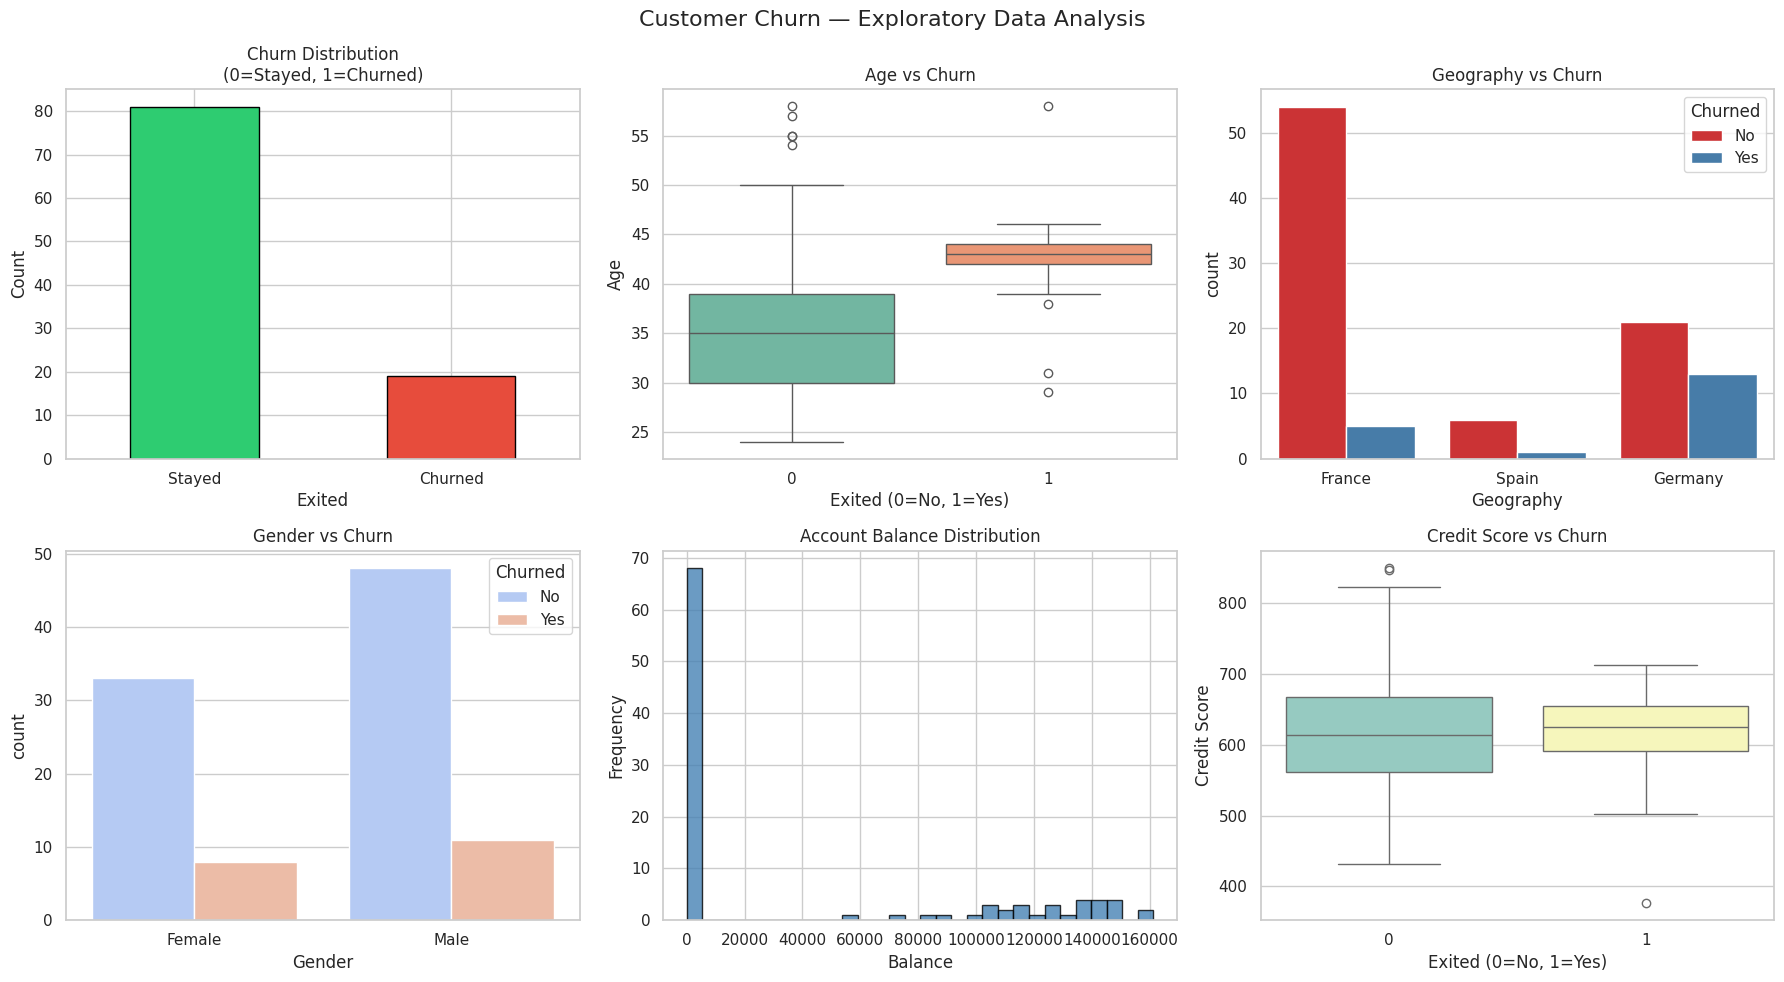

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Churn Distribution
df['Exited'].value_counts().plot(
    kind='bar', ax=axes[0,0],
    color=['#2ecc71','#e74c3c'], edgecolor='black'
)
axes[0,0].set_title('Churn Distribution\n(0=Stayed, 1=Churned)')
axes[0,0].set_xlabel('Exited')
axes[0,0].set_ylabel('Count')
axes[0,0].set_xticklabels(['Stayed','Churned'], rotation=0)

# 2. Age vs Churn
sns.boxplot(data=df, x='Exited', y='Age',
            hue='Exited', palette='Set2',
            legend=False, ax=axes[0,1])
axes[0,1].set_title('Age vs Churn')
axes[0,1].set_xlabel('Exited (0=No, 1=Yes)')
axes[0,1].set_ylabel('Age')

# 3. Geography vs Churn
sns.countplot(data=df, x='Geography',
              hue='Exited', palette='Set1', ax=axes[0,2])
axes[0,2].set_title('Geography vs Churn')
axes[0,2].set_xlabel('Geography')
axes[0,2].legend(title='Churned', labels=['No','Yes'])

# 4. Gender vs Churn
sns.countplot(data=df, x='Gender',
              hue='Exited', palette='coolwarm', ax=axes[1,0])
axes[1,0].set_title('Gender vs Churn')
axes[1,0].set_xlabel('Gender')
axes[1,0].legend(title='Churned', labels=['No','Yes'])

# 5. Balance Distribution
df['Balance'].plot(kind='hist', bins=30,
                   color='steelblue', edgecolor='black',
                   alpha=0.8, ax=axes[1,1])
axes[1,1].set_title('Account Balance Distribution')
axes[1,1].set_xlabel('Balance')
axes[1,1].set_ylabel('Frequency')

# 6. Credit Score vs Churn
sns.boxplot(data=df, x='Exited', y='CreditScore',
            hue='Exited', palette='Set3',
            legend=False, ax=axes[1,2])
axes[1,2].set_title('Credit Score vs Churn')
axes[1,2].set_xlabel('Exited (0=No, 1=Yes)')
axes[1,2].set_ylabel('Credit Score')

plt.suptitle('Customer Churn — Exploratory Data Analysis', fontsize=16)
plt.tight_layout()
plt.show()

In [13]:
df_encoded = df.copy()

# Label Encoding for binary column
le = LabelEncoder()
df_encoded['Gender'] = le.fit_transform(df_encoded['Gender'])

# One-Hot Encoding for Geography
df_encoded = pd.get_dummies(df_encoded, columns=['Geography'], drop_first=True)

print("✅ Encoding complete!")
print("Columns after encoding:", df_encoded.columns.tolist())
df_encoded.head()
    

✅ Encoding complete!
Columns after encoding: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain']


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


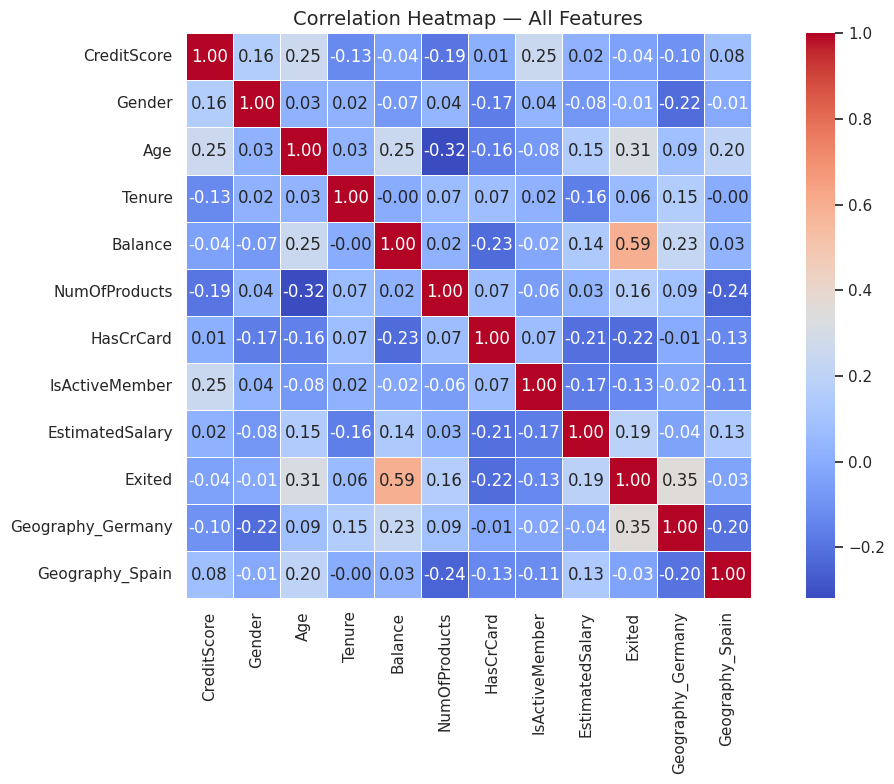

In [14]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    df_encoded.corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    square=True
)
plt.title('Correlation Heatmap — All Features', fontsize=14)
plt.tight_layout()
plt.show()

In [15]:
X = df_encoded.drop('Exited', axis=1)
y = df_encoded['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("✅ Data split & scaled!")
print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)

✅ Data split & scaled!
Train size: (80, 11)
Test size:  (20, 11)


In [16]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
lr_preds = lr.predict(X_test_sc)
lr_acc = accuracy_score(y_test, lr_preds)

# Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
dt_preds = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_preds)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)

print(f"✅ Logistic Regression Accuracy : {lr_acc*100:.2f}%")
print(f"✅ Decision Tree Accuracy        : {dt_acc*100:.2f}%")
print(f"✅ Random Forest Accuracy        : {rf_acc*100:.2f}%")

✅ Logistic Regression Accuracy : 90.00%
✅ Decision Tree Accuracy        : 90.00%
✅ Random Forest Accuracy        : 95.00%


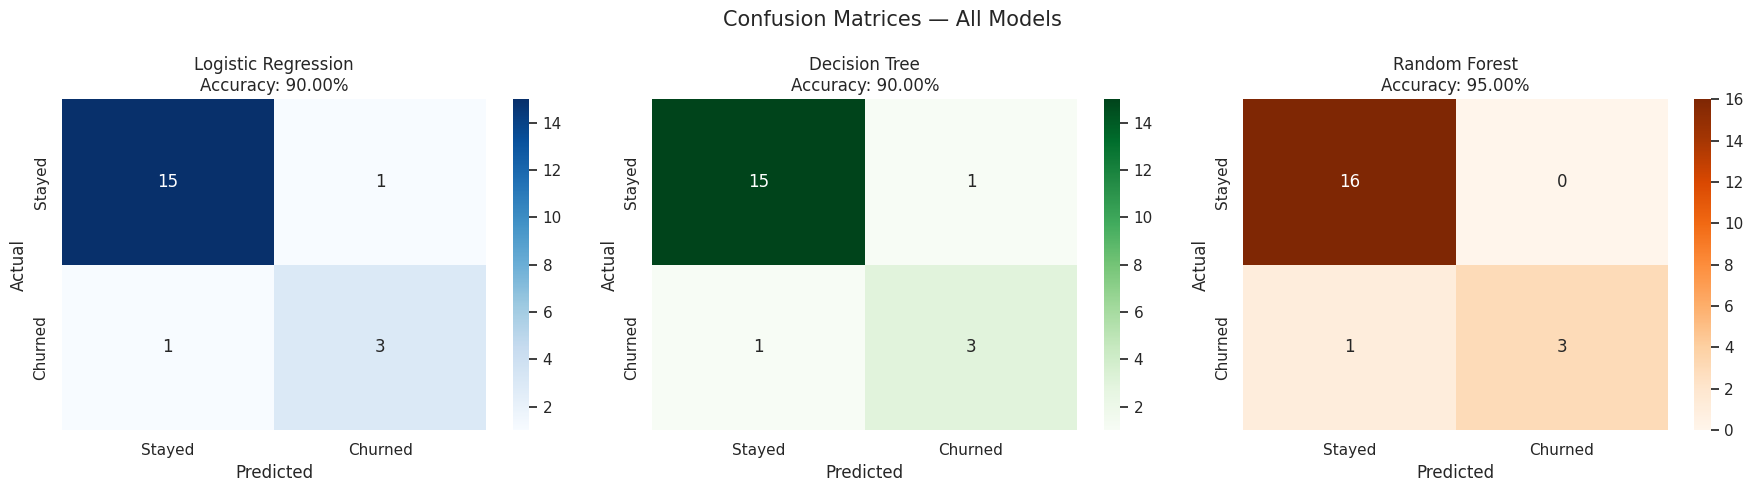

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, preds, acc, title, cmap in zip(
    axes,
    [lr_preds, dt_preds, rf_preds],
    [lr_acc, dt_acc, rf_acc],
    ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    ['Blues', 'Greens', 'Oranges']
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Stayed','Churned'],
                yticklabels=['Stayed','Churned'])
    ax.set_title(f'{title}\nAccuracy: {acc*100:.2f}%', fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=15)
plt.tight_layout()
plt.show()

  LOGISTIC REGRESSION
              precision    recall  f1-score   support

      Stayed       0.94      0.94      0.94        16
     Churned       0.75      0.75      0.75         4

    accuracy                           0.90        20
   macro avg       0.84      0.84      0.84        20
weighted avg       0.90      0.90      0.90        20

  DECISION TREE
              precision    recall  f1-score   support

      Stayed       0.94      0.94      0.94        16
     Churned       0.75      0.75      0.75         4

    accuracy                           0.90        20
   macro avg       0.84      0.84      0.84        20
weighted avg       0.90      0.90      0.90        20

  RANDOM FOREST
              precision    recall  f1-score   support

      Stayed       0.94      1.00      0.97        16
     Churned       1.00      0.75      0.86         4

    accuracy                           0.95        20
   macro avg       0.97      0.88      0.91        20
weighted avg       0

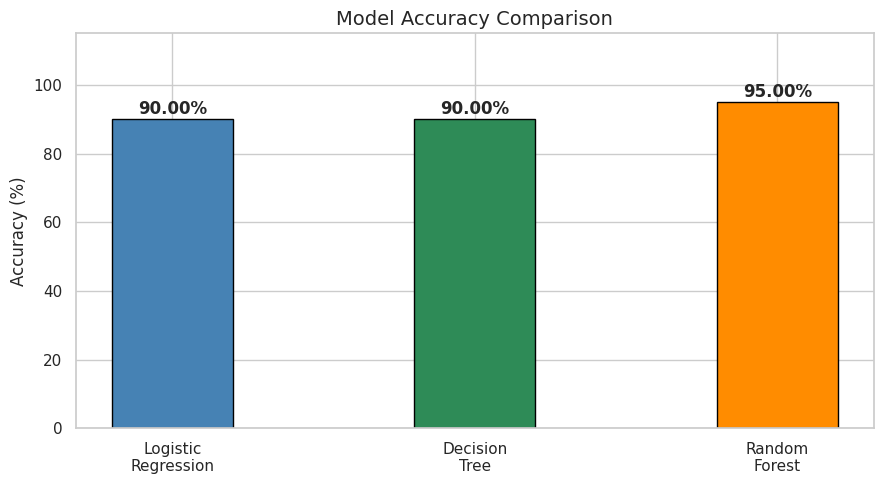

In [18]:
# Print reports
for name, preds in [('LOGISTIC REGRESSION', lr_preds),
                    ('DECISION TREE', dt_preds),
                    ('RANDOM FOREST', rf_preds)]:
    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, preds,
          target_names=['Stayed', 'Churned']))

# Accuracy bar chart
models = ['Logistic\nRegression', 'Decision\nTree', 'Random\nForest']
accs   = [lr_acc*100, dt_acc*100, rf_acc*100]
colors = ['steelblue', 'seagreen', 'darkorange']

plt.figure(figsize=(9, 5))
bars = plt.bar(models, accs, color=colors, edgecolor='black', width=0.4)
plt.ylim(0, 115)
plt.title('Model Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy (%)')

for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1.5,
             f'{acc:.2f}%', ha='center',
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

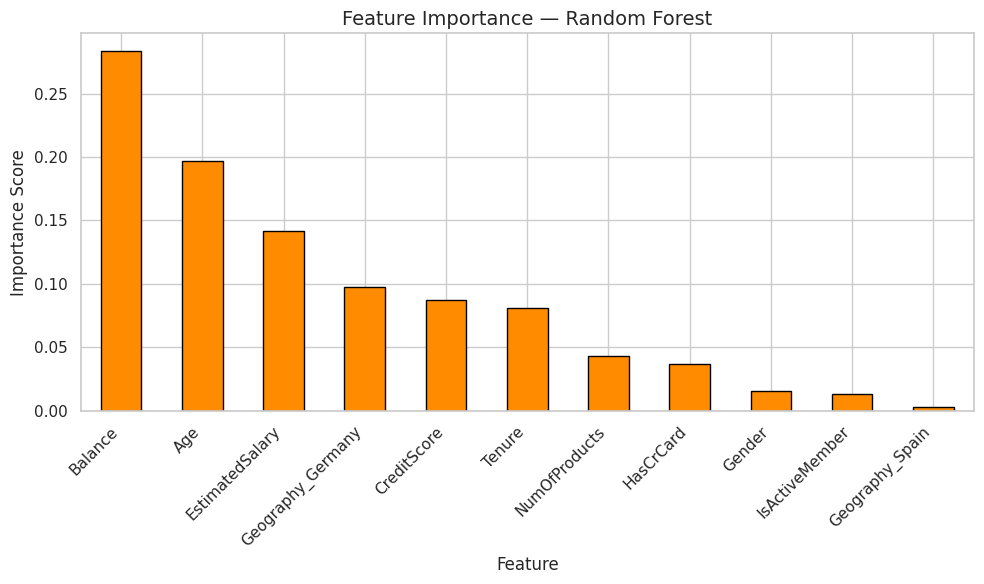


Top 5 Features influencing Churn:
Balance              0.283318
Age                  0.197019
EstimatedSalary      0.141941
Geography_Germany    0.097622
CreditScore          0.087060
dtype: float64


In [19]:
feat_imp = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='bar', color='darkorange', edgecolor='black')
plt.title('Feature Importance — Random Forest', fontsize=14)
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 5 Features influencing Churn:")
print(feat_imp.head())
